# 03 — SHAP Explanations

Computes **TreeSHAP attributions** for XGBoost replicas of every window pair, restricted to the flagged instances F_{A,B}.

**Model-type awareness:** When `MODEL_TYPE == 'logreg'` this notebook prints a skip message and stops — Logistic Regression uses its coefficients as the explanation; no post-hoc XAI is needed. SHAP is only computed when `MODEL_TYPE == 'xgboost'`.

**Input:** `data/models/{model_type}/pair_{i:02d}/` (from notebook 02)  
**Output per pair (XGBoost only):** under `data/shap/{model_type}/pair_{i:02d}/`
- `shap_A.npy` — shape `(R, |F_{A,B}|, p)`
- `shap_B.npy` — shape `(R, |F_{A,B}|, p)`
- `expected_values_A.npy` — shape `(R,)` — per-replica SHAP base value (log-odds)
- `expected_values_B.npy` — shape `(R,)`
- `stochasticity.json` — §3.9 explainer-stochasticity diagnostic per pair

---

**TreeSHAP note (§3.3):** XGBoost models were trained on **unscaled** features; SHAP attributions are therefore computed on raw feature values (no scaler applied). TreeSHAP is deterministic for a fixed model — this notebook verifies that claim for every pair.

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import json
import joblib
import numpy as np
import pandas as pd
import shap
from pathlib import Path

WORKSPACE = Path('/content/drive/MyDrive/Thesis/Shoppers_workspace')
PROC_DIR  = WORKSPACE / 'data' / 'processed'
WIN_DIR   = WORKSPACE / 'data' / 'windows'

# ── Model type — must match the MODEL_TYPE used in notebook 02 ────────
MODEL_TYPE = 'xgboost'   # 'xgboost' or 'logreg'

MODEL_DIR = WORKSPACE / 'data' / 'models' / MODEL_TYPE
SHAP_DIR  = WORKSPACE / 'data' / 'shap'  / MODEL_TYPE
SHAP_DIR.mkdir(parents=True, exist_ok=True)

print(f'SHAP version: {shap.__version__}')
print(f'MODEL_TYPE : {MODEL_TYPE}')

SHAP version: 0.51.0
MODEL_TYPE : xgboost


In [13]:
# Load data and window config
X      = pd.read_parquet(PROC_DIR / 'X.parquet').values.astype(np.float32)
with open(PROC_DIR / 'feature_names.json') as f:
    feature_names_json = json.load(f)
feature_names = feature_names_json['all']   # flat list of 119 feature names in column order

with open(WIN_DIR / 'window_config.json') as f:
    config = json.load(f)

R     = config['parameters']['R']
pairs = config['pairs']

print(f'X: {X.shape}, features: {len(feature_names)}')
print(f'R={R}, {len(pairs)} pairs')

X: (160057, 119), features: 119
R=8, 2 pairs


## SHAP computation loop

For each pair and each replica:
1. Load the model (XGBoost was trained on unscaled data — no scaler needed here).
2. Compute TreeSHAP values via `shap.TreeExplainer` on the raw (unscaled) flagged instances.
3. Capture `explainer.expected_value` (log-odds base value) per replica.

Results are saved immediately after each pair to allow resuming.

In [14]:
if MODEL_TYPE != 'xgboost':
    print(f'MODEL_TYPE is "{MODEL_TYPE}" — SHAP computation skipped.')
    print('Logistic Regression uses its coefficients as the explanation; no post-hoc XAI is needed.')
else:
    for p in pairs:
        pid       = p['pair_id']
        pair_dir  = MODEL_DIR / f'pair_{pid:02d}'
        shap_dir  = SHAP_DIR  / f'pair_{pid:02d}'

        shap_A_path = shap_dir / 'shap_A.npy'
        shap_B_path = shap_dir / 'shap_B.npy'

        if shap_A_path.exists() and shap_B_path.exists():
            print(f'Pair {pid:02d}: SHAP already computed, skipping.')
            continue

        print(f'\n── Pair {pid:02d} ──────────────────────────────────────────────')
        shap_dir.mkdir(parents=True, exist_ok=True)

        # Load prediction data
        pred_data = np.load(pair_dir / 'predictions.npz')
        flagged_local_idx = pred_data['flagged_idx']   # positions within idx_eval
        idx_eval = np.array(p['idx_eval'], dtype=np.int64)

        # Global row indices of flagged instances
        flagged_global_idx = idx_eval[flagged_local_idx]
        X_flagged = X[flagged_global_idx]   # (|F|, p) — raw, unscaled (XGBoost was trained on unscaled data)

        n_flagged = X_flagged.shape[0]
        n_feat    = X_flagged.shape[1]
        print(f'  Flagged instances: {n_flagged:,}  Features: {n_feat}')

        if n_flagged == 0:
            print('  WARNING: no flagged instances — skipping.')
            continue

        # ── SHAP for replicas of window A ─────────────────────────────────
        shap_A = np.zeros((R, n_flagged, n_feat), dtype=np.float32)
        ev_A   = np.zeros(R, dtype=np.float32)   # per-replica expected values (log-odds base values)
        for r in range(R):
            model = joblib.load(pair_dir / 'replicas_A' / f'model_r{r}.joblib')
            explainer = shap.TreeExplainer(model)
            vals = explainer.shap_values(X_flagged)
            # For binary classification XGBoost returns a 2D array directly
            # or a list [neg_class, pos_class]; we want positive class
            if isinstance(vals, list):
                vals = vals[1]
            shap_A[r] = vals.astype(np.float32)
            raw_ev = explainer.expected_value
            ev_A[r] = np.float32(raw_ev if not isinstance(raw_ev, list) else raw_ev[1])
            print(f'  A replica {r}: SHAP computed  |mean|={np.abs(shap_A[r]).mean():.5f}  base={ev_A[r]:.4f}')

        # ── SHAP for replicas of window B ─────────────────────────────────
        shap_B = np.zeros((R, n_flagged, n_feat), dtype=np.float32)
        ev_B   = np.zeros(R, dtype=np.float32)
        for r in range(R):
            model = joblib.load(pair_dir / 'replicas_B' / f'model_r{r}.joblib')
            explainer = shap.TreeExplainer(model)
            vals = explainer.shap_values(X_flagged)
            if isinstance(vals, list):
                vals = vals[1]
            shap_B[r] = vals.astype(np.float32)
            raw_ev = explainer.expected_value
            ev_B[r] = np.float32(raw_ev if not isinstance(raw_ev, list) else raw_ev[1])
            print(f'  B replica {r}: SHAP computed  |mean|={np.abs(shap_B[r]).mean():.5f}  base={ev_B[r]:.4f}')

        # ── Sanity check: SHAP values should sum to log-odds prediction − base_value ──
        # Check replica 0 of A using the saved expected value (no need to rebuild the explainer)
        model_A0  = joblib.load(pair_dir / 'replicas_A' / 'model_r0.joblib')
        preds_raw = model_A0.predict(X_flagged, output_margin=True)  # log-odds
        shap_sum  = shap_A[0].sum(axis=1) + ev_A[0]
        max_err   = np.abs(shap_sum - preds_raw).max()
        print(f'  Sanity (A r0): max |SHAP_sum - log_odds| = {max_err:.6f}')
        if max_err > 0.01:
            print('  WARNING: SHAP consistency error too large!')
        else:
            print('  Sanity check passed.')

        # ── Save ──────────────────────────────────────────────────────────
        np.save(shap_A_path, shap_A)
        np.save(shap_B_path, shap_B)
        np.save(shap_dir / 'expected_values_A.npy', ev_A)
        np.save(shap_dir / 'expected_values_B.npy', ev_B)
        print(f'  Saved shap_A {shap_A.shape}, shap_B {shap_B.shape}, expected_values A/B (R={R})')

    print('\n✓ All SHAP values computed.')


── Pair 00 ──────────────────────────────────────────────
  Flagged instances: 5,158  Features: 119
  A replica 0: SHAP computed  |mean|=0.07536  base=-1.3594
  A replica 1: SHAP computed  |mean|=0.07173  base=-1.3613
  A replica 2: SHAP computed  |mean|=0.07379  base=-1.3640
  A replica 3: SHAP computed  |mean|=0.06449  base=-1.3544
  A replica 4: SHAP computed  |mean|=0.08030  base=-1.3600
  A replica 5: SHAP computed  |mean|=0.08022  base=-1.3604
  A replica 6: SHAP computed  |mean|=0.06977  base=-1.3620
  A replica 7: SHAP computed  |mean|=0.07569  base=-1.3591
  B replica 0: SHAP computed  |mean|=0.08483  base=-1.2574
  B replica 1: SHAP computed  |mean|=0.08895  base=-1.2540
  B replica 2: SHAP computed  |mean|=0.08798  base=-1.2528
  B replica 3: SHAP computed  |mean|=0.08496  base=-1.2593
  B replica 4: SHAP computed  |mean|=0.08980  base=-1.2550
  B replica 5: SHAP computed  |mean|=0.08873  base=-1.2525
  B replica 6: SHAP computed  |mean|=0.08346  base=-1.2618
  B replica 7:

## SHAP stochasticity diagnostic (§3.9)

TreeSHAP is deterministic — running the explainer twice on the same model and data returns identical values. We verify this **for every pair** using the best-performing A replica (selected by PR-AUC from `per_replica_pr_auc_A`), and save the result as `stochasticity.json` per pair for use in notebook 04.

In [15]:
if MODEL_TYPE == 'xgboost':
    for p in pairs:
        pid      = p['pair_id']
        pair_dir = MODEL_DIR / f'pair_{pid:02d}'
        shap_dir = SHAP_DIR  / f'pair_{pid:02d}'
        shap_dir.mkdir(parents=True, exist_ok=True)

        print(f'\n── Pair {pid:02d} stochasticity diagnostic ──')

        pred_data = np.load(pair_dir / 'predictions.npz')
        idx_eval  = np.array(p['idx_eval'], dtype=np.int64)
        flagged_local_idx  = pred_data['flagged_idx']
        flagged_global_idx = idx_eval[flagged_local_idx]
        X_flagged = X[flagged_global_idx]   # unscaled — no scaler needed

        # Best replica of A = highest per-replica PR-AUC (saved by notebook 02)
        per_auc_A = pred_data['per_replica_pr_auc_A']   # (R,)
        best_r    = int(np.argmax(per_auc_A))
        print(f'  Best replica of A: r={best_r}  (PR-AUC={per_auc_A[best_r]:.4f})')

        model_best = joblib.load(pair_dir / 'replicas_A' / f'model_r{best_r}.joblib')
        exp = shap.TreeExplainer(model_best)

        # Run explainer twice
        run1 = exp.shap_values(X_flagged)
        if isinstance(run1, list): run1 = run1[1]
        run2 = exp.shap_values(X_flagged)
        if isinstance(run2, list): run2 = run2[1]

        max_abs_diff = float(np.abs(run1 - run2).max())
        is_det = max_abs_diff < 1e-6
        print(f'  Max |run1 - run2|: {max_abs_diff:.2e}')
        print('  TreeSHAP is deterministic ✓' if is_det else '  WARNING: non-zero stochasticity!')

        stoch = {
            'best_replica_A':   best_r,
            'max_abs_diff':     max_abs_diff,
            'is_deterministic': is_det,
        }
        with open(shap_dir / 'stochasticity.json', 'w') as f:
            json.dump(stoch, f, indent=2)
        print(f'  Saved stochasticity.json')

    print('\n✓ Stochasticity diagnostic complete.')


── Pair 00 stochasticity diagnostic ──
  Best replica of A: r=6  (PR-AUC=0.4314)
  Max |run1 - run2|: 0.00e+00
  TreeSHAP is deterministic ✓
  Saved stochasticity.json

── Pair 01 stochasticity diagnostic ──
  Best replica of A: r=1  (PR-AUC=0.4261)
  Max |run1 - run2|: 0.00e+00
  TreeSHAP is deterministic ✓
  Saved stochasticity.json

✓ Stochasticity diagnostic complete.


## Quick SHAP summary (pair 0)

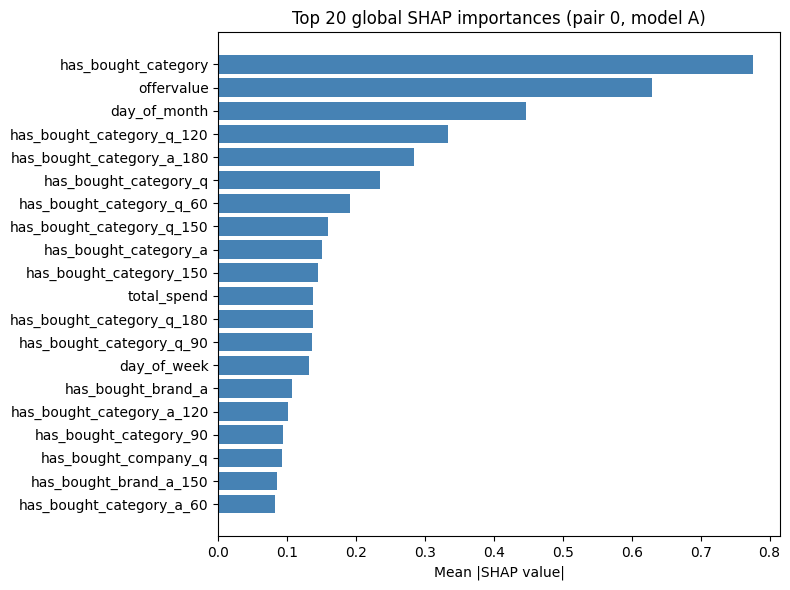

In [16]:
if MODEL_TYPE == 'xgboost':
    import matplotlib.pyplot as plt

    shap_A_0 = np.load(SHAP_DIR / 'pair_00' / 'shap_A.npy')   # (R, |F|, p)

    # Replica-averaged SHAP for pair 0
    phi_bar_A = shap_A_0.mean(axis=0)   # (|F|, p)

    # Global importance: mean |φ| per feature
    global_imp = np.abs(phi_bar_A).mean(axis=0)
    top_k = 20
    top_idx = np.argsort(global_imp)[::-1][:top_k]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(
        [feature_names[i] for i in top_idx[::-1]],
        global_imp[top_idx[::-1]],
        color='steelblue'
    )
    ax.set_title(f'Top {top_k} global SHAP importances (pair 0, model A)')
    ax.set_xlabel('Mean |SHAP value|')
    plt.tight_layout()
    plt.savefig(SHAP_DIR / 'global_importance_pair00_A.png', dpi=120)
    plt.show()